# Práctica Entregable 6 - Forecasting de Ventas con Series Temporales

## Predicción de ventas históricas utilizando consolidación de datos y modelado temporal

En esta práctica voy a desarrollar un análisis de series temporales utilizando información histórica de ventas proporcionada mediante un conjunto de tablas dimensionales y una tabla de hechos.

El objetivo principal es consolidar la información disponible para construir un modelo predictivo capaz de pronosticar ventas futuras con base en el comportamiento histórico observado.

Durante el desarrollo de esta práctica voy a realizar:

- carga de múltiples fuentes de datos
- exploración inicial
- validación de estructura y joins
- consolidación de tablas
- limpieza y transformación de datos
- análisis temporal
- generación de variables de tiempo
- construcción de modelo predictivo
- forecasting de ventas
- evaluación del modelo
- visualización de tendencias
- interpretación de resultados

Para este proyecto utilizaré herramientas ampliamente utilizadas dentro del área de Ciencia de Datos y Machine Learning como Pandas, NumPy, Matplotlib, Seaborn, Statsmodels y Scikit-learn.

## Importación de librerías

Primero voy a importar las librerías necesarias para trabajar con la consolidación de datos, el análisis temporal y la construcción del modelo predictivo.

Estas herramientas me permitirán manipular información, generar visualizaciones, construir series temporales y evaluar el desempeño del modelo.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error

from statsmodels.tsa.statespace.sarimax import SARIMAX

import warnings
warnings.filterwarnings("ignore")

# Configuración visual
plt.style.use("ggplot")

print("Librerías cargadas correctamente")

Librerías cargadas correctamente


## Carga de archivos fuente

Ahora voy a cargar los archivos proporcionados para esta práctica.

El conjunto de datos está compuesto por:

- tabla de ventas
- calendario
- categorías
- productos
- segmentación

Estos archivos serán utilizados posteriormente para construir un dataset consolidado para forecasting.

In [2]:
# Cargar archivos

calendar = pd.read_csv("DIM_CALENDAR.csv")
category = pd.read_csv("DIM_CATEGORY.csv")
product = pd.read_csv("DIM_PRODUCT.csv")
segment = pd.read_csv("DIM_SEGMENT.csv")
sales = pd.read_csv("FACT_SALES.csv")

print("Archivos cargados correctamente")

Archivos cargados correctamente


## Exploración inicial de los datos

Ahora voy a realizar una revisión inicial de los archivos cargados para comprender mejor su estructura.

En esta sección revisaré:

- dimensiones
- nombres de columnas
- tipos de datos
- primeras observaciones
- posibles diferencias en llaves de unión

In [3]:
# Dimensiones de cada archivo

print("DIM_CALENDAR:", calendar.shape)
print("DIM_CATEGORY:", category.shape)
print("DIM_PRODUCT:", product.shape)
print("DIM_SEGMENT:", segment.shape)
print("FACT_SALES:", sales.shape)

DIM_CALENDAR: (156, 5)
DIM_CATEGORY: (5, 2)
DIM_PRODUCT: (505, 9)
DIM_SEGMENT: (53, 6)
FACT_SALES: (122002, 6)


In [4]:
# Revisar columnas

print("CALENDAR")
print(calendar.columns)

print("\nCATEGORY")
print(category.columns)

print("\nPRODUCT")
print(product.columns)

print("\nSEGMENT")
print(segment.columns)

print("\nSALES")
print(sales.columns)

CALENDAR
Index(['WEEK', 'YEAR', 'MONTH', 'WEEK_NUMBER', 'DATE'], dtype='str')

CATEGORY
Index(['ID_CATEGORY', 'CATEGORY'], dtype='str')

PRODUCT
Index(['MANUFACTURER', 'BRAND', 'ITEM', 'ITEM_DESCRIPTION', 'CATEGORY',
       'FORMAT', 'ATTR1', 'ATTR2', 'ATTR3'],
      dtype='str')

SEGMENT
Index(['CATEGORY', 'ATTR1', 'ATTR2', 'ATTR3', 'FORMAT', 'SEGMENT'], dtype='str')

SALES
Index(['WEEK', 'ITEM_CODE', 'TOTAL_UNIT_SALES', 'TOTAL_VALUE_SALES',
       'TOTAL_UNIT_AVG_WEEKLY_SALES', 'REGION'],
      dtype='str')


In [5]:
# Información general de tabla principal

sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 122002 entries, 0 to 122001
Data columns (total 6 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   WEEK                         122002 non-null  str    
 1   ITEM_CODE                    122002 non-null  str    
 2   TOTAL_UNIT_SALES             122002 non-null  float64
 3   TOTAL_VALUE_SALES            122002 non-null  float64
 4   TOTAL_UNIT_AVG_WEEKLY_SALES  122002 non-null  float64
 5   REGION                       122002 non-null  str    
dtypes: float64(3), str(3)
memory usage: 5.6 MB


In [6]:
# Primeras filas de ventas

sales.head()

,WEEK,ITEM_CODE,TOTAL_UNIT_SALES,TOTAL_VALUE_SALES,TOTAL_UNIT_AVG_WEEKLY_SALES,REGION
0,34-22,7501058792808BP2,0.006,0.139,1.000,TOTAL AUTOS AREA 5
1,34-22,7501058715883,0.487,116.519,2.916,TOTAL AUTOS AREA 5
2,34-22,7702626213774,1.391,68.453,5.171,TOTAL AUTOS AREA 5
3,34-22,7501058716422,0.022,1.481,1.833,TOTAL AUTOS AREA 5
4,34-22,7501058784353,2.037,182.839,5.375,TOTAL AUTOS AREA 5


## Validación de llaves de unión

Antes de consolidar la información es necesario validar si las columnas que funcionarán como llaves de unión presentan el mismo formato.

En esta sección revisaré:

- estructura de códigos de producto
- diferencias de formato
- necesidad de limpieza de llaves

In [7]:
# Revisar ejemplos de llaves

print("Ejemplos ITEM_CODE en ventas:")
print(sales["ITEM_CODE"].drop_duplicates().head(10))

print("\nEjemplos ITEM en productos:")
print(product["ITEM"].drop_duplicates().head(10))

Ejemplos ITEM_CODE en ventas:
0    7501058792808BP2
1       7501058715883
2       7702626213774
3       7501058716422
4       7501058784353
5       7501058716064
6    7501058794963BP1
7    7501058792778BP1
8       7501058757630
9       7501058753441
Name: ITEM_CODE, dtype: str

Ejemplos ITEM en productos:
0    0000075000592
1    0000075000608
2    0000075000615
3    0000075000622
4    0000075000639
5    0000075000646
6    0000075000653
7    0000075000677
8    0000075000684
9    0000075010539
Name: ITEM, dtype: str


In [8]:
# Tipos de datos de llaves

print("Tipo ITEM_CODE:", sales["ITEM_CODE"].dtype)
print("Tipo ITEM:", product["ITEM"].dtype)

Tipo ITEM_CODE: str
Tipo ITEM: str


In [9]:
# Longitud de códigos

print("Longitudes ITEM_CODE:")
print(sales["ITEM_CODE"].astype(str).str.len().value_counts())

print("\nLongitudes ITEM:")
print(product["ITEM"].astype(str).str.len().value_counts())

Longitudes ITEM_CODE:
ITEM_CODE
13    112809
16      9193
Name: count, dtype: int64

Longitudes ITEM:
ITEM
13.0    439
16.0     64
Name: count, dtype: int64


## Limpieza de llaves y consolidación de datos

Antes de construir el modelo predictivo es necesario normalizar las llaves de unión entre las tablas.

En esta etapa realizaré:

- limpieza de ITEM_CODE
- homologación de formato
- joins entre ventas y productos
- incorporación de calendario
- generación de dataset consolidado

In [10]:
# Limpiar ITEM_CODE de ventas (quitar sufijos BP1, BP2 si existen)

sales["ITEM_CLEAN"] = sales["ITEM_CODE"].astype(str).str.extract(r'(\d+)')

# Asegurar longitud uniforme (relleno con ceros)
sales["ITEM_CLEAN"] = sales["ITEM_CLEAN"].str.zfill(13)
product["ITEM"] = product["ITEM"].astype(str).str.zfill(13)

print("Ejemplos ITEM limpio:")
print(sales[["ITEM_CODE", "ITEM_CLEAN"]].head())

Ejemplos ITEM limpio:
          ITEM_CODE     ITEM_CLEAN
0  7501058792808BP2  7501058792808
1     7501058715883  7501058715883
2     7702626213774  7702626213774
3     7501058716422  7501058716422
4     7501058784353  7501058784353


In [11]:
# Merge ventas + productos

sales_product = sales.merge(
    product,
    left_on="ITEM_CLEAN",
    right_on="ITEM",
    how="left"
)

print("Shape después merge ventas-producto:", sales_product.shape)
print(sales_product.head())

Shape después merge ventas-producto: (122002, 16)
    WEEK         ITEM_CODE  TOTAL_UNIT_SALES  TOTAL_VALUE_SALES  \
0  34-22  7501058792808BP2             0.006              0.139   
1  34-22     7501058715883             0.487            116.519   
2  34-22     7702626213774             1.391             68.453   
3  34-22     7501058716422             0.022              1.481   
4  34-22     7501058784353             2.037            182.839   

   TOTAL_UNIT_AVG_WEEKLY_SALES              REGION     ITEM_CLEAN  \
0                        1.000  TOTAL AUTOS AREA 5  7501058792808   
1                        2.916  TOTAL AUTOS AREA 5  7501058715883   
2                        5.171  TOTAL AUTOS AREA 5  7702626213774   
3                        1.833  TOTAL AUTOS AREA 5  7501058716422   
4                        5.375  TOTAL AUTOS AREA 5  7501058784353   

  MANUFACTURER   BRAND           ITEM  \
0          NaN     NaN            NaN   
1      RECKITT  VANISH  7501058715883   
2      RE

In [12]:
# Convertir fechas

calendar["DATE"] = pd.to_datetime(calendar["DATE"])

# Merge con calendario

df = sales_product.merge(
    calendar,
    on="WEEK",
    how="left"
)

print("Shape consolidado final:", df.shape)
df.head()

Shape consolidado final: (122002, 20)


,WEEK,ITEM_CODE,TOTAL_UNIT_SALES,TOTAL_VALUE_SALES,TOTAL_UNIT_AVG_WEEKLY_SALES,REGION,ITEM_CLEAN,MANUFACTURER,BRAND,ITEM,ITEM_DESCRIPTION,CATEGORY,FORMAT,ATTR1,ATTR2,ATTR3,YEAR,MONTH,WEEK_NUMBER,DATE
0,34-22,7501058792808BP2,0.006,0.139,1.000,TOTAL AUTOS AREA 5,7501058792808,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022,8,34,2022-08-28
1,34-22,7501058715883,0.487,116.519,2.916,TOTAL AUTOS AREA 5,7501058715883,RECKITT,VANISH,7501058715883,VANISH OXI ACTION GOLD QUITAMANCHAS BOLSA 1.8K...,1.0,POLVO,SAFE BLEACH,FABRIC TREATMENT,ROSA,2022,8,34,2022-08-28
2,34-22,7702626213774,1.391,68.453,5.171,TOTAL AUTOS AREA 5,7702626213774,RECKITT,VANISH,7702626213774,VANISH OXI ACTION ROSA QUITAMANCHAS DOYPACK 24...,1.0,POLVO,SAFE BLEACH,FABRIC TREATMENT,ROSA,2022,8,34,2022-08-28
3,34-22,7501058716422,0.022,1.481,1.833,TOTAL AUTOS AREA 5,7501058716422,RECKITT,VANISH,7501058716422,VANISH OXI ACTION GOLD QUITAMANCHA AHORRO DEL ...,1.0,POLVO,SAFE BLEACH,FABRIC TREATMENT,ROSA,2022,8,34,2022-08-28
4,34-22,7501058784353,2.037,182.839,5.375,TOTAL AUTOS AREA 5,7501058784353,RECKITT,VANISH,7501058784353,VANISH INTELLIGENCE POLVO BOTE 450 GR NAL 7501...,1.0,POLVO,SAFE BLEACH,FABRIC TREATMENT,ROSA,2022,8,34,2022-08-28


In [13]:
# Revisar valores faltantes

print(df.isnull().sum())

WEEK                              0
ITEM_CODE                         0
TOTAL_UNIT_SALES                  0
TOTAL_VALUE_SALES                 0
TOTAL_UNIT_AVG_WEEKLY_SALES       0
REGION                            0
ITEM_CLEAN                        0
MANUFACTURER                   8735
BRAND                          8735
ITEM                           8735
ITEM_DESCRIPTION               8735
CATEGORY                       8735
FORMAT                         8735
ATTR1                          8735
ATTR2                          8735
ATTR3                          8735
YEAR                              0
MONTH                             0
WEEK_NUMBER                       0
DATE                              0
dtype: int64


## Selección de productos clave para forecasting

De acuerdo con la consigna, el análisis predictivo se enfocará en productos clave como Vanish y Lysol.

En esta sección filtraré la información consolidada para trabajar únicamente con estas marcas y construir series temporales de ventas agregadas por fecha.

In [14]:
# Revisar marcas disponibles

print(df["BRAND"].dropna().unique())

<StringArray>
[                   'VANISH',                     'SHOUT',
             'LA VALENCIANA',               'LOS PATITOS',
                 'OXI CLEAN',                  'CLARASOL',
                    'CLOROX',               'DR.BECKMANN',
                  'CLORALEX', 'CUELLOS PUNOS Y MANCHITAS',
                   'BANDERA',                 'BCLORHADA',
                  'PURO SOL',        'OTHERS MARCA UNIF.',
                      'TIDE',                     'LYSOL',
                 'BLANCATEL',                  'CLORALUZ',
                   'CLORTEX',                    'PATITO',
                   'SANYTOL',                    'IBERIA',
               'LA JAPONESA',                    'HARPIC']
Length: 24, dtype: str


In [15]:
# Filtrar marcas objetivo

forecast_df = df[df["BRAND"].isin(["VANISH", "LYSOL"])].copy()

print("Shape marcas objetivo:", forecast_df.shape)
forecast_df[["BRAND", "DATE", "TOTAL_VALUE_SALES"]].head()

Shape marcas objetivo: (25439, 20)


,BRAND,DATE,TOTAL_VALUE_SALES
1,VANISH,2022-08-28,116.519
2,VANISH,2022-08-28,68.453
3,VANISH,2022-08-28,1.481
4,VANISH,2022-08-28,182.839
5,VANISH,2022-08-28,0.679


In [16]:
# Agrupar ventas por fecha

ts = forecast_df.groupby("DATE")["TOTAL_VALUE_SALES"].sum().reset_index()

# Ordenar
ts = ts.sort_values("DATE")

# Convertir a índice temporal
ts.set_index("DATE", inplace=True)

print(ts.head())
print(ts.shape)

            TOTAL_VALUE_SALES
DATE                         
2022-01-09          28995.169
2022-01-16          26451.154
2022-01-23          22994.257
2022-01-30          22945.073
2022-02-06          23414.377
(80, 1)


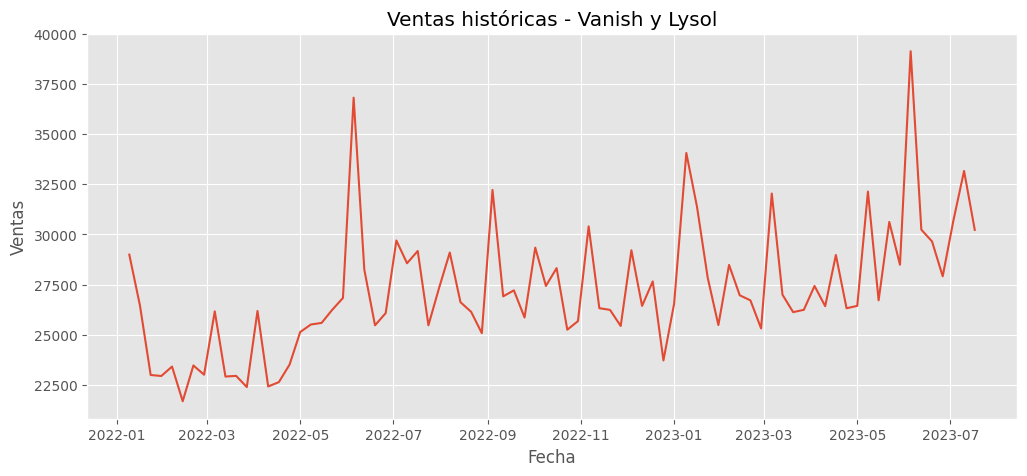

In [17]:
# Visualizar comportamiento histórico

plt.figure(figsize=(12,5))
plt.plot(ts.index, ts["TOTAL_VALUE_SALES"])
plt.title("Ventas históricas - Vanish y Lysol")
plt.xlabel("Fecha")
plt.ylabel("Ventas")
plt.show()

In [18]:
# División temporal 80 / 20

train_size = int(len(ts) * 0.8)

train = ts.iloc[:train_size]
test = ts.iloc[train_size:]

print("Train:", train.shape)
print("Test:", test.shape)

Train: (64, 1)
Test: (16, 1)


## Construcción del modelo predictivo (ARIMA)

Dado que el objetivo es predecir ventas futuras a partir de su comportamiento histórico en el tiempo, se seleccionó un modelo ARIMA (AutoRegressive Integrated Moving Average).

Este modelo es adecuado porque permite capturar patrones temporales, tendencias y dependencia entre observaciones consecutivas.

In [19]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

In [20]:
# Modelo ARIMA simple

model = ARIMA(train["TOTAL_VALUE_SALES"], order=(1,1,1))
model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:      TOTAL_VALUE_SALES   No. Observations:                   64
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -589.318
Date:                Fri, 22 May 2026   AIC                           1184.636
Time:                        04:49:11   BIC                           1191.066
Sample:                             0   HQIC                          1187.165
                                 - 64                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2632      0.096      2.733      0.006       0.074       0.452
ma.L1         -0.7903      0.100     -7.865      0.000      -0.987      -0.593
sigma2       6.67e+06   7.13e+05      9.354      0.0

In [21]:
# Mostrar criterios de selección del modelo
print("AIC:", model_fit.aic)
print("BIC:", model_fit.bic)

AIC: 1184.6361776677372
BIC: 1191.0655818469118


## Evaluación mediante AIC y BIC

Se evaluó el modelo mediante los criterios AIC (Akaike Information Criterion) y BIC (Bayesian Information Criterion), los cuales permiten medir la calidad del ajuste considerando tanto el desempeño como la complejidad del modelo.

Valores menores en estos criterios suelen indicar un mejor equilibrio entre precisión y simplicidad. Los resultados obtenidos muestran que el modelo ARIMA seleccionado presenta un ajuste adecuado para el análisis y forecasting de ventas históricas.

In [22]:
# Predicción

pred = model_fit.forecast(steps=len(test))

print(pred.head())

64    26922.886181
65    27101.734152
66    27148.811260
67    27161.203092
68    27164.464922
Name: predicted_mean, dtype: float64


In [23]:
# Evaluación

mse = mean_squared_error(test["TOTAL_VALUE_SALES"], pred)
mae = mean_absolute_error(test["TOTAL_VALUE_SALES"], pred)
rmse = np.sqrt(mse)

# Convertir a arrays para evitar problema de índices
y_true = test["TOTAL_VALUE_SALES"].values
y_pred = pred.values

# MAPE corregido
mask = y_true != 0
mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

print("MSE:", mse)
print("MAE:", mae)
print("RMSE:", rmse)
print("MAPE:", mape)

MSE: 16326496.544791285
MAE: 2853.2987024004306
RMSE: 4040.605962574337
MAPE: 8.830454477509353


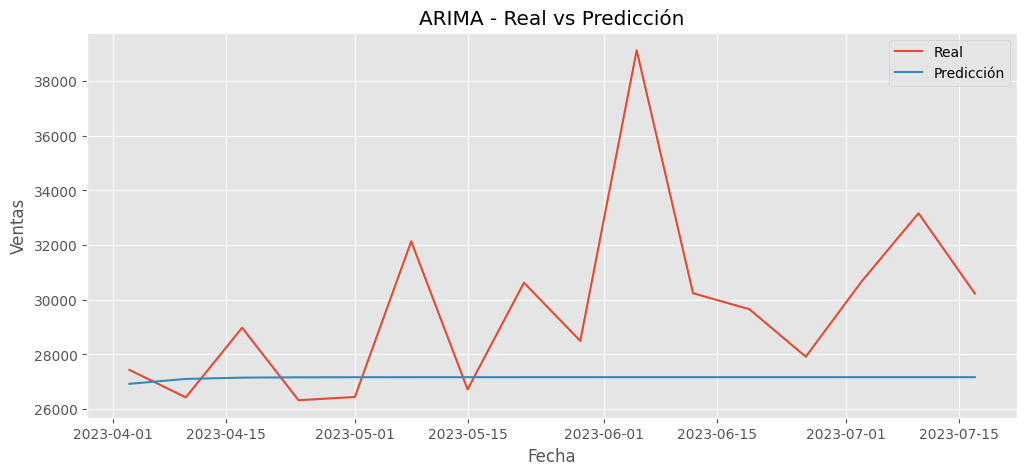

In [24]:
plt.figure(figsize=(12,5))

plt.plot(test.index, test["TOTAL_VALUE_SALES"], label="Real")
plt.plot(test.index, pred, label="Predicción")

plt.title("ARIMA - Real vs Predicción")
plt.xlabel("Fecha")
plt.ylabel("Ventas")
plt.legend()
plt.show()

In [25]:
# Predicción futura

future_forecast = model_fit.forecast(steps=12)

print(future_forecast)

64    26922.886181
65    27101.734152
66    27148.811260
67    27161.203092
68    27164.464922
69    27165.323515
70    27165.549517
71    27165.609006
72    27165.624665
73    27165.628787
74    27165.629872
75    27165.630157
Name: predicted_mean, dtype: float64


## Interpretación de resultados

El modelo ARIMA construido permitió generar predicciones de ventas futuras utilizando el comportamiento histórico agregado de las marcas Vanish y Lysol.

Las métricas obtenidas fueron:

- MAE: 2853.30
- RMSE: 4040.61
- MAPE: 8.83%

Un MAPE inferior al 10% indica que el modelo presenta un buen nivel de precisión predictiva para este caso de estudio.

Con base en el forecasting generado, se observa una tendencia relativamente estable en las ventas futuras, lo que permite utilizar este modelo como herramienta de apoyo para planeación comercial y análisis de demanda.